# AirIntel — Notebook 10: Advanced Analytics & Intelligence

Using the feature-engineered and audited dataset, we conduct unsupervised clustering (city & weather regimes), spatial hotspots mapping, temporal bimodal distributions, persistence of pollution episodes, community detection over daily correlation networks, and high-dimensional projections (PCA, t-SNE, UMAP).

## 01. Imports

Load libraries for clustering, networks, dimensional reduction, and visual plotting.

In [1]:
# Import required libraries

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# File handling
from pathlib import Path
import time
import joblib

# Numerical computing & data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.stats import kruskal

# Network analysis
import networkx as nx

# Dimensionality reduction
try:
    import umap
    umap_available = True
except ImportError:
    umap_available = False

## 02. Configuration

Configure folders and reproducibility settings.

In [2]:
# Configure paths and parameters
PROJECT_DIR = Path(r"c:\Users\kayri\OneDrive - IIT BHU\Documents\Indian_Air_Quality_Project")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
REPORT_DIR = PROJECT_DIR / "reports"
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR = REPORT_DIR / "figures" / "10_Advanced_Analytics"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 03. Load Engineered Data

Read the audited feature-engineered dataset containing 72 features + target variables.

In [3]:
# Load parquet file
parquet_path = DATA_DIR / "processed" / "feature_engineered_airintel.parquet"
df = pd.read_parquet(parquet_path)
if not pd.api.types.is_datetime64_any_dtype(df['Datetime']):
    df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Date'] = df['Datetime'].dt.date
print(f"Dataset shape: {df.shape}")

Dataset shape: (842160, 248)


## 04. Data Verification

Print sample records to verify loaded variables.

In [4]:
# View first few rows
df.head()

,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,SO2_ugm3_Change,SO2_ugm3_PctChange,O3_ugm3_Change,O3_ugm3_PctChange,PM2_5_ugm3_Volatility_24H,PM10_ugm3_Volatility_24H,CO_ugm3_Volatility_24H,NO2_ugm3_Volatility_24H,SO2_ugm3_Volatility_24H,O3_ugm3_Volatility_24H
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,0.3,0.111111,1.0,0.031250,0.450000,0.650000,0.500000,1.650000,0.150000,0.500000
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,0.3,0.100000,1.0,0.030303,0.616441,0.828654,0.471405,2.735365,0.244949,0.816497
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,0.0,0.000000,-2.0,-0.058824,1.017349,1.408900,0.500000,3.030986,0.248747,0.829156
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,-0.1,-0.030303,-2.0,-0.062500,1.238386,1.712776,1.095445,3.046572,0.228035,1.326650


---------------------------------
### SECTION A: CITY INTELLIGENCE
---------------------------------

## 05. City Aggregation

Aggregate records to compile city-level metrics with advanced statistical profiles.

In [5]:
# Aggregation helpers
def compute_iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

def compute_pct90(x):
    return np.percentile(x, 90)

# Aggregate at city level
city_profile = df.groupby(['City', 'State']).agg(
    Average_AQI=('US_AQI', 'mean'),
    Median_AQI=('US_AQI', 'median'),
    AQI_Standard_Deviation=('US_AQI', 'std'),
    AQI_Variance=('US_AQI', 'var'),
    AQI_Maximum=('US_AQI', 'max'),
    AQI_Minimum=('US_AQI', 'min'),
    AQI_90th_Percentile=('US_AQI', compute_pct90),
    AQI_Interquartile_Range=('US_AQI', compute_iqr),
    Observation_Count=('US_AQI', 'count'),
    Average_PM25=('PM2_5_ugm3', 'mean'),
    Average_PM10=('PM10_ugm3', 'mean'),
    Average_NO2=('NO2_ugm3', 'mean'),
    Average_SO2=('SO2_ugm3', 'mean'),
    Average_CO=('CO_ugm3', 'mean'),
    Average_O3=('O3_ugm3', 'mean'),
    Average_Temperature=('Temp_2m_C', 'mean'),
    Average_Humidity=('Humidity_Percent', 'mean'),
    Average_Pressure=('Pressure_MSL_hPa', 'mean'),
    Average_Wind_Speed=('Wind_Speed_10m_kmh', 'mean'),
    Average_Rainfall=('Precipitation_mm', 'mean')
).reset_index()

city_profile.columns = [
    'City', 'State', 'Average AQI', 'AQI Median', 'AQI Standard Deviation', 'AQI Variance',
    'AQI Maximum', 'AQI Minimum', 'AQI 90th Percentile', 'AQI Interquartile Range (IQR)', 'Observation Count',
    'Average PM2.5', 'Average PM10', 'Average NO2', 'Average SO2', 'Average CO', 'Average O3',
    'Average Temperature', 'Average Humidity', 'Average Pressure', 'Average Wind Speed', 'Average Rainfall'
]

city_profile['AQI Coefficient of Variation (CV)'] = city_profile['AQI Standard Deviation'] / city_profile['Average AQI']
city_profile['AQI Standard Deviation'] = city_profile['AQI Standard Deviation'].fillna(0)
city_profile['AQI Variance'] = city_profile['AQI Variance'].fillna(0)
city_profile['AQI Coefficient of Variation (CV)'] = city_profile['AQI Coefficient of Variation (CV)'].fillna(0)

city_profile.to_csv(TABLE_DIR / "city_profile.csv", index=False)
city_profile.head()

,City,State,Average AQI,AQI Median,AQI Standard Deviation,AQI Variance,AQI Maximum,AQI Minimum,AQI 90th Percentile,AQI Interquartile Range (IQR),...,Average NO2,Average SO2,Average CO,Average O3,Average Temperature,Average Humidity,Average Pressure,Average Wind Speed,Average Rainfall,AQI Coefficient of Variation (CV)
0,Agartala,Tripura,105.529292,104.0,48.106059,2314.192872,233.0,13.0,NaN,NaN,...,22.762490,6.236636,389.074966,74.028891,25.539855,78.654304,1008.418643,8.097390,0.209669,0.455855
1,Ahmedabad,Gujarat,89.117272,80.0,33.600311,1128.980908,213.0,12.0,NaN,NaN,...,20.233085,10.684969,381.624242,67.924415,27.742242,55.515083,1008.401515,9.625282,0.126312,0.377035
2,Aizawl,Mizoram,59.562046,51.0,34.780684,1209.695976,215.0,9.0,NaN,NaN,...,5.729909,1.908244,285.837087,62.375034,19.008144,78.423898,1010.216791,4.250258,0.196477,0.583940
3,Bengaluru,Karnataka,66.771242,66.0,32.164338,1034.544623,204.0,12.0,NaN,NaN,...,16.720227,7.395096,379.315840,68.147555,23.407817,70.129580,1011.591622,12.052621,0.117813,0.481709
4,Bhopal,Madhya Pradesh,85.037954,78.0,33.341902,1111.682447,178.0,12.0,NaN,NaN,...,5.729914,5.838581,300.812741,83.647142,24.880341,61.449862,1009.292865,9.471191,0.153657,0.392083


## 06. Pollution Profiles

Compare relative pollutant patterns across cities using a heatmap.

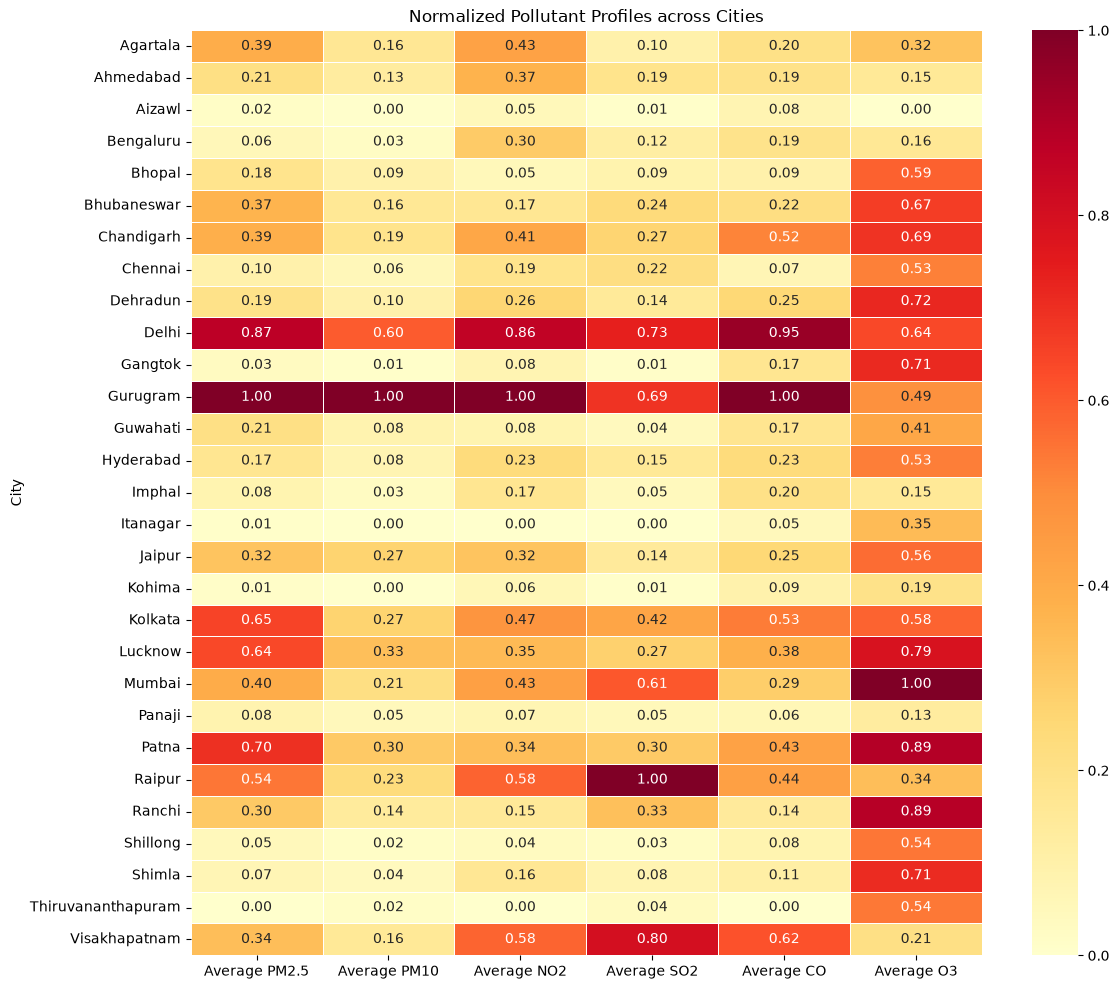

In [6]:
# Plot normalized pollutant heatmap
plt.figure(figsize=(12, 10))
pollutants_cols = ['Average PM2.5', 'Average PM10', 'Average NO2', 'Average SO2', 'Average CO', 'Average O3']
profile_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(city_profile[pollutants_cols]),
    columns=pollutants_cols,
    index=city_profile['City']
)
sns.heatmap(profile_scaled, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Normalized Pollutant Profiles across Cities")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_heatmaps.png", dpi=300)
plt.show()

## 07. City Clustering

Standardize features for unsupervised city-level grouping.

In [7]:
# Extract and scale features
clustering_features = [
    'Average AQI', 'Average PM2.5', 'Average PM10', 'Average NO2', 'Average SO2', 'Average CO', 'Average O3',
    'Average Temperature', 'Average Humidity', 'Average Pressure', 'Average Wind Speed', 'Average Rainfall'
]
X_city = city_profile[clustering_features]
scaler_city = StandardScaler()
X_city_scaled = scaler_city.fit_transform(X_city)

## 08. Cluster Validation

Evaluate K-means using silhouette, Davies-Bouldin, and Calinski-Harabasz metrics to automatically determine optimal K.

In [8]:
# Evaluate metrics from K=2 to 6
k_range = range(2, 7)
elbow_scores = []
sil_scores = []
ch_scores = []
db_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_city_scaled)
    elbow_scores.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_city_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_city_scaled, labels))
    db_scores.append(davies_bouldin_score(X_city_scaled, labels))

# Balanced K Selection using Rank Aggregation
sil_ranks = len(k_range) - np.argsort(sil_scores).argsort()
ch_ranks = len(k_range) - np.argsort(ch_scores).argsort()
db_ranks = np.argsort(db_scores).argsort() + 1
avg_ranks = (sil_ranks + ch_ranks + db_ranks) / 3.0
best_k = list(k_range)[np.argmin(avg_ranks)]
print(f"Multi-metric balanced optimal K selected: {best_k}")

Multi-metric balanced optimal K selected: 2


## 09. Cluster Visualization

Plot validation curves showing elbow and silhouette scores together.

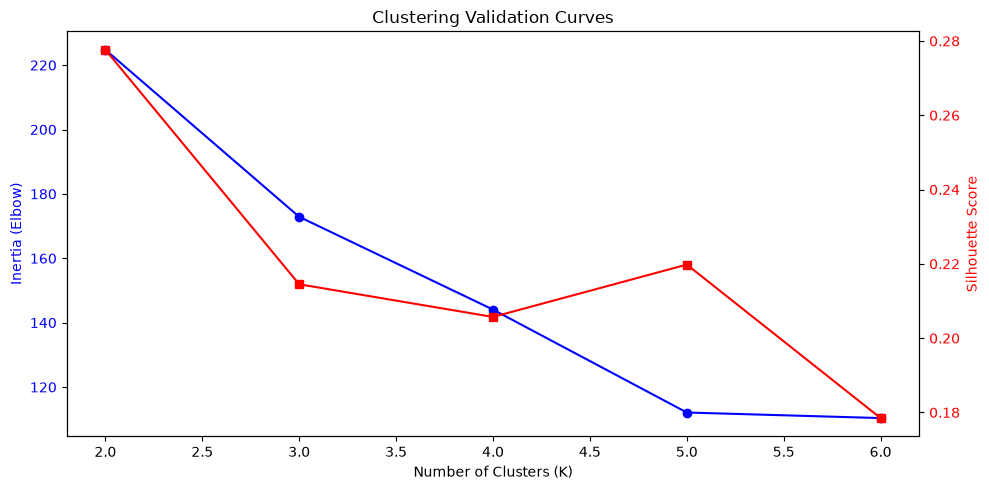

In [9]:
# Plot validation curves
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, elbow_scores, 'b-o')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Elbow)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'r-s')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title("Clustering Validation Curves")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "elbow_curve.png", dpi=300)
plt.show()

## 10. Cluster Interpretation

Fit optimal K-means and interpret cluster signatures statistically.

In [10]:
# Fit final models and define profile names
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE)
city_profile['Cluster'] = kmeans_final.fit_predict(X_city_scaled)

hierarchical = AgglomerativeClustering(n_clusters=best_k)
city_profile['Hierarchical_Cluster'] = hierarchical.fit_predict(X_city_scaled)

cluster_interpretation = []
for c in range(best_k):
    c_data = city_profile[city_profile['Cluster'] == c]
    mean_aqi = c_data['Average AQI'].mean()
    mean_temp = c_data['Average Temperature'].mean()
    mean_rain = c_data['Average Rainfall'].mean()
    mean_humidity = c_data['Average Humidity'].mean()
    if mean_aqi < 70:
        aqi_desc = "Clean Air"
    elif mean_aqi < 130:
        aqi_desc = "Moderate Air"
    else:
        aqi_desc = "Highly Polluted"
    if mean_humidity > 70:
        weather_desc = "Humid Coastal/Tropical"
    elif mean_temp > 24:
        weather_desc = "Hot Dry Inland"
    else:
        weather_desc = "Temperate"
    if mean_rain > city_profile['Average Rainfall'].median():
        rain_desc = "High Precipitation"
    else:
        rain_desc = "Low Precipitation"
    name = f"{aqi_desc} - {weather_desc} ({rain_desc})"
    cluster_interpretation.append({
        "Cluster": c,
        "Cluster Name": name,
        "City Count": len(c_data),
        "Cities": ", ".join(c_data['City'].tolist()),
        "Mean AQI": mean_aqi,
        "Mean Temp": mean_temp,
        "Mean Rainfall": mean_rain
    })

cluster_summary_df = pd.DataFrame(cluster_interpretation)
cluster_summary_df.to_csv(TABLE_DIR / "cluster_summary.csv", index=False)
city_profile[['City', 'State', 'Cluster', 'Hierarchical_Cluster']].to_csv(TABLE_DIR / "city_clusters.csv", index=False)
cluster_summary_df

,Cluster,Cluster Name,City Count,Cities,Mean AQI,Mean Temp,Mean Rainfall
0,0,Clean Air - Humid Coastal/Tropical (High Preci...,12,"Aizawl, Bengaluru, Dehradun, Gangtok, Guwahati...",69.937326,20.589310,0.251529
1,1,Moderate Air - Hot Dry Inland (Low Precipitation),17,"Agartala, Ahmedabad, Bhopal, Bhubaneswar, Chan...",115.769426,25.773705,0.159871


## 11. Cluster Radar Charts

Generate cluster radar plots to visualize pollutant signatures using normalized values for visualization only.

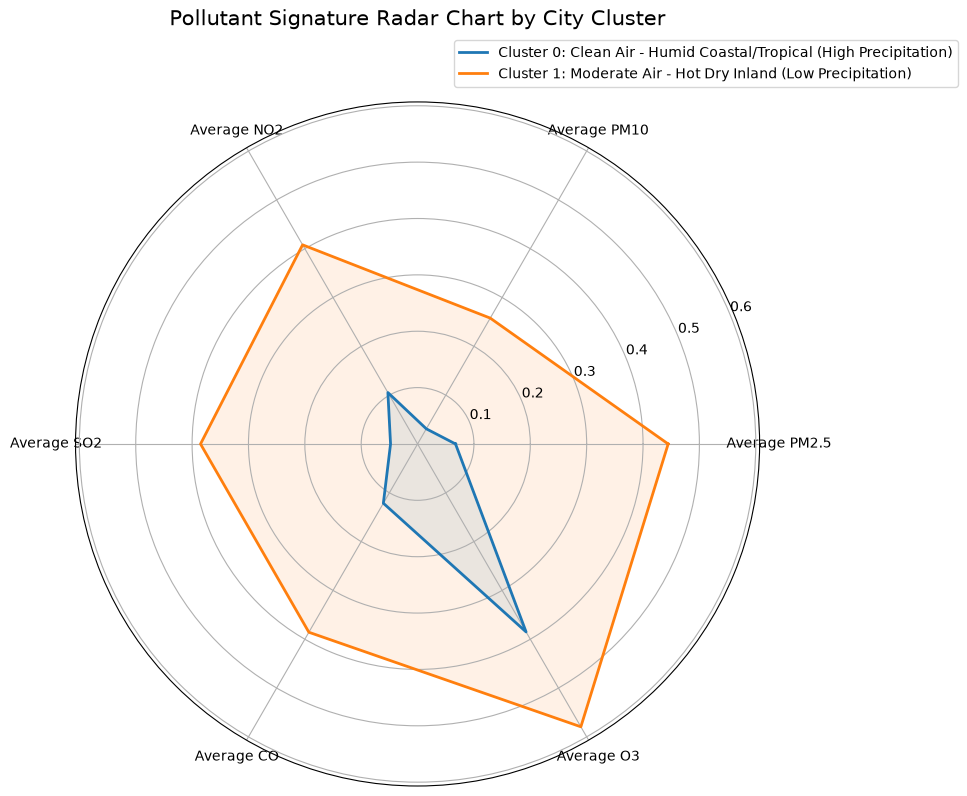

In [11]:
# Generate polar radar plot
plt.figure(figsize=(10, 8))
categories = pollutants_cols
N = len(categories)
scaler_radar = MinMaxScaler()
radar_data = pd.DataFrame(scaler_radar.fit_transform(city_profile[categories]), columns=categories)
radar_data['Cluster'] = city_profile['Cluster']
cluster_centroids = radar_data.groupby('Cluster').mean()

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories, size=10)

for c in range(best_k):
    values = cluster_centroids.loc[c].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"Cluster {c}: {cluster_summary_df.loc[c, 'Cluster Name']}")
    ax.fill(angles, values, alpha=0.1)

plt.title("Pollutant Signature Radar Chart by City Cluster", size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_radar_charts.png", dpi=300)
plt.show()

## 12. City Similarity Engine

Calculate cosine similarity and Euclidean-based similarity measures between cities.

In [12]:
# Calculate similarity matrices
sim_matrix_cosine = cosine_similarity(X_city_scaled)
sim_df_cosine = pd.DataFrame(sim_matrix_cosine, index=city_profile['City'], columns=city_profile['City'])
sim_df_cosine.to_csv(TABLE_DIR / "city_similarity.csv")

dist_matrix_euclidean = euclidean_distances(X_city_scaled)
sim_matrix_euclidean = 1.0 / (1.0 + dist_matrix_euclidean)
sim_df_euclidean = pd.DataFrame(sim_matrix_euclidean, index=city_profile['City'], columns=city_profile['City'])
sim_df_euclidean.to_csv(TABLE_DIR / "city_similarity_euclidean.csv")

similarity_list = []
for city in city_profile['City']:
    similar = sim_df_cosine[city].sort_values(ascending=False).index[1:5].tolist()
    similar_euc = sim_df_euclidean[city].sort_values(ascending=False).index[1:5].tolist()
    similarity_list.append({
        "City": city,
        "Most_Similar_Cosine_1": similar[0],
        "Most_Similar_Cosine_2": similar[1],
        "Most_Similar_Euclidean_1": similar_euc[0],
        "Most_Similar_Euclidean_2": similar_euc[1]
    })
city_sim_df = pd.DataFrame(similarity_list)
city_sim_df.to_csv(TABLE_DIR / "city_similarity_pairs.csv", index=False)
city_sim_df.head(10)

,City,Most_Similar_Cosine_1,Most_Similar_Cosine_2,Most_Similar_Euclidean_1,Most_Similar_Euclidean_2
0,Agartala,Guwahati,Kolkata,Bhubaneswar,Guwahati
1,Ahmedabad,Jaipur,Hyderabad,Jaipur,Hyderabad
2,Aizawl,Imphal,Itanagar,Imphal,Itanagar
3,Bengaluru,Hyderabad,Imphal,Hyderabad,Imphal
4,Bhopal,Hyderabad,Jaipur,Hyderabad,Ranchi
5,Bhubaneswar,Chennai,Patna,Agartala,Chennai
6,Chandigarh,Lucknow,Jaipur,Jaipur,Lucknow
7,Chennai,Thiruvananthapuram,Panaji,Bhubaneswar,Hyderabad
8,Dehradun,Shimla,Gangtok,Ranchi,Imphal
9,Delhi,Gurugram,Lucknow,Gurugram,Raipur


## 13. Similarity Matrix Heatmap

Plot similarity heatmap between cities.

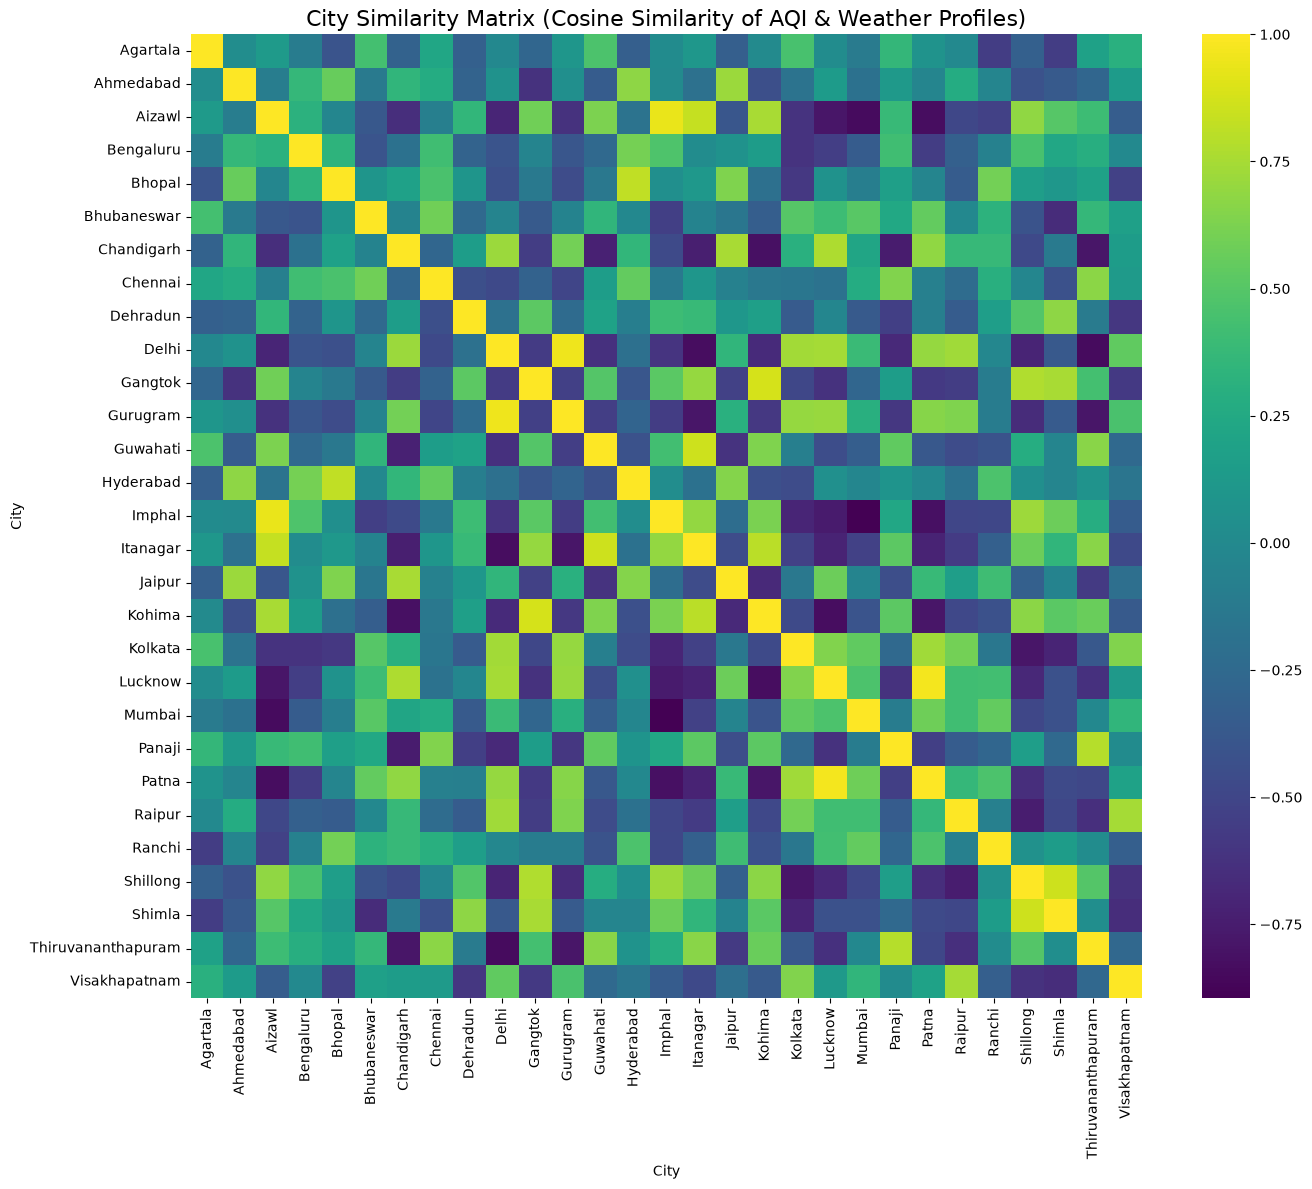

In [13]:
# Plot similarity matrix
plt.figure(figsize=(14, 12))
sns.heatmap(sim_df_cosine, cmap="viridis", annot=False)
plt.title("City Similarity Matrix (Cosine Similarity of AQI & Weather Profiles)", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "similarity_heatmap.png", dpi=300)
plt.show()

---------------------------------
### SECTION B: WEATHER INTELLIGENCE
---------------------------------

## 14. Weather Regime Discovery

Perform clustering on weather observations (including encoded Season if available).

In [14]:
# Scale weather sample and encode Season
df_sample = df.sample(n=min(50000, len(df)), random_state=RANDOM_STATE)
weather_features = [
    'Temp_2m_C', 'Humidity_Percent', 'Pressure_MSL_hPa', 'Precipitation_mm',
    'Wind_Speed_10m_kmh', 'Cloud_Cover_Percent'
]
X_weather = df_sample[weather_features]

if 'Season' in df.columns:
    season_dummies = pd.get_dummies(df_sample['Season'], prefix='Season')
    X_weather_combined = pd.concat([X_weather, season_dummies], axis=1)
else:
    X_weather_combined = X_weather

scaler_weather = StandardScaler()
X_weather_scaled = scaler_weather.fit_transform(X_weather_combined)

## 15. Weather Clustering

Fit weather clustering and associate regime names dynamically.

In [15]:
# Fit weather clustering model
kmeans_weather = KMeans(n_clusters=4, random_state=RANDOM_STATE)
df_sample['Weather_Cluster'] = kmeans_weather.fit_predict(X_weather_scaled)

weather_centroids = scaler_weather.inverse_transform(kmeans_weather.cluster_centers_)[:, :6]
weather_regimes = {}
for i, centroid in enumerate(weather_centroids):
    temp, hum, pres, prec, wind, cloud = centroid
    if prec > 0.5:
        regimes_name = "Rainy/Wet"
    elif wind > 15:
        regimes_name = "Windy/Breezy"
    elif hum > 75:
        regimes_name = "Humid/Overcast" if cloud > 50 else "Humid/Mild"
    elif temp > 28:
        regimes_name = "Hot/Dry"
    else:
        regimes_name = "Moderate/Clear"
    weather_regimes[i] = regimes_name

df_sample['Weather_Regime'] = df_sample['Weather_Cluster'].map(weather_regimes)
df_sample[['Temp_2m_C', 'Humidity_Percent', 'Weather_Regime']].head(10)

,Temp_2m_C,Humidity_Percent,Weather_Regime
160063,29.3,61,Moderate/Clear
541575,30.6,74,Humid/Overcast
322601,17.1,48,Moderate/Clear
794503,25.2,93,Moderate/Clear
483702,22.5,80,Moderate/Clear
64165,32.1,20,Moderate/Clear
817902,20.9,97,Moderate/Clear
118128,20.5,53,Moderate/Clear
503077,25.5,74,Humid/Overcast
703657,24.7,20,Moderate/Clear


## 16. Pollution Across Weather Clusters

Compare pollution distribution across identified weather regimes.

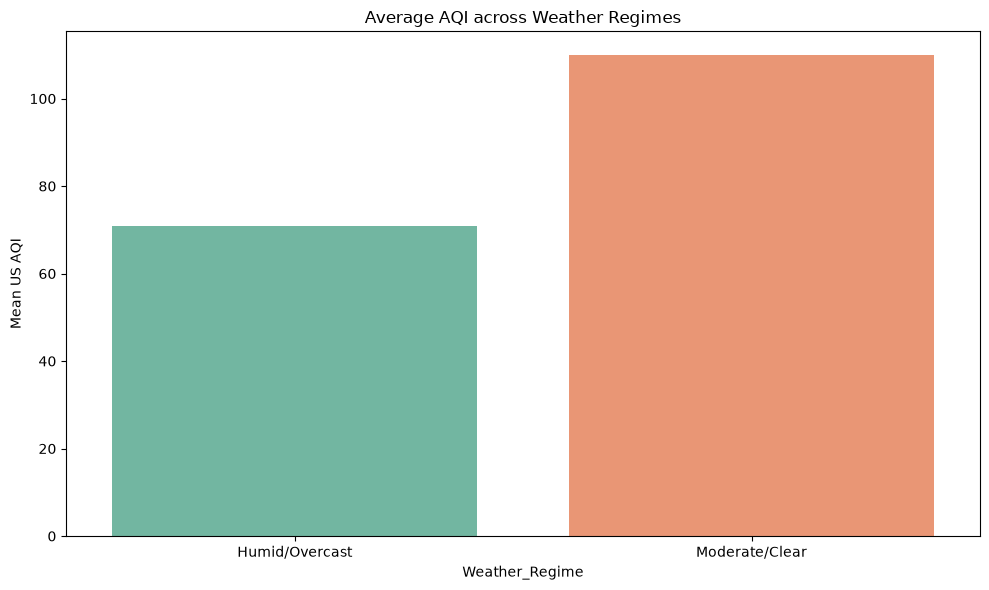

In [16]:
# Compare pollution stats across regimes
weather_pollution = df_sample.groupby('Weather_Regime').agg(
    Mean_AQI=('US_AQI', 'mean'),
    Mean_PM25=('PM2_5_ugm3', 'mean'),
    Mean_PM10=('PM10_ugm3', 'mean'),
    Mean_O3=('O3_ugm3', 'mean'),
    Observation_Count=('US_AQI', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=weather_pollution, x="Weather_Regime", y="Mean_AQI", palette="Set2")
plt.title("Average AQI across Weather Regimes")
plt.ylabel("Mean US AQI")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "weather_cluster_comparison.png", dpi=300)
plt.show()

---------------------------------
### SECTION C: SPATIAL INTELLIGENCE
---------------------------------

## 17. Pollution Hotspots

Identify spatial regions with severe average pollution using hexbins and KDE plots.

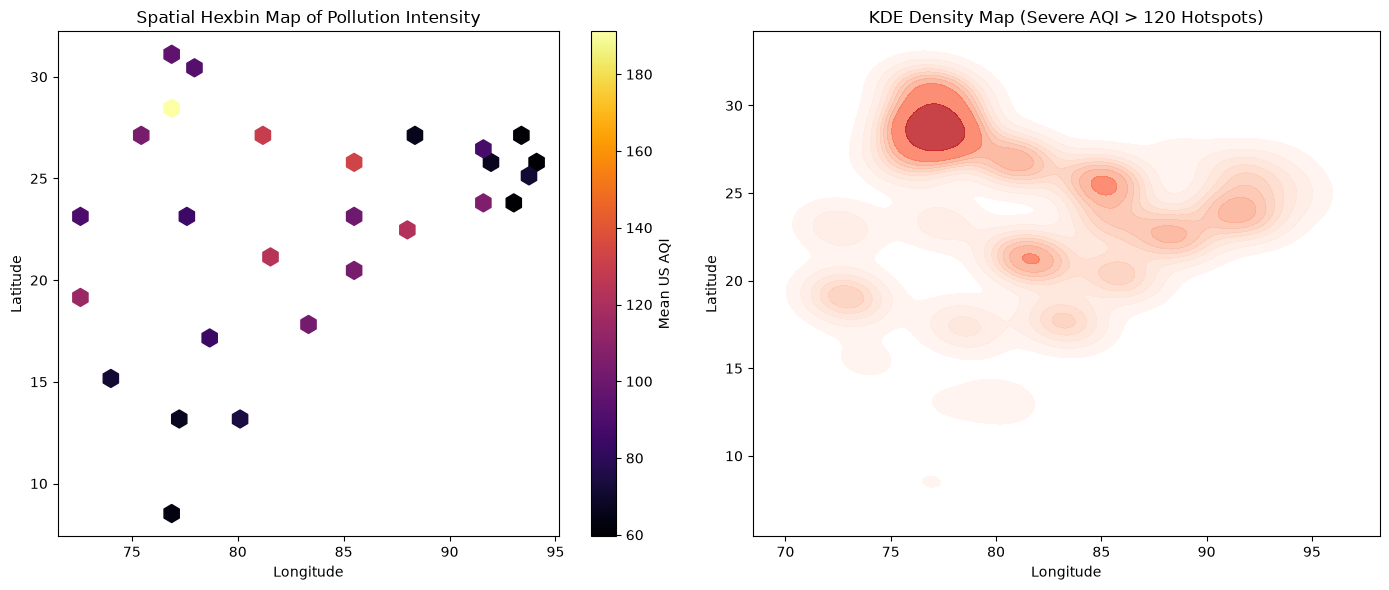

In [17]:
# Plot spatial hotspot hexbin map and KDE density map
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hexbin(df['Longitude'], df['Latitude'], C=df['US_AQI'], gridsize=30, cmap='inferno', reduce_C_function=np.mean)
plt.colorbar(label='Mean US AQI')
plt.title("Spatial Hexbin Map of Pollution Intensity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.subplot(1, 2, 2)
high_pollution_obs = df[df['US_AQI'] > 120].sample(n=min(5000, len(df[df['US_AQI'] > 120])), random_state=RANDOM_STATE)
sns.kdeplot(data=high_pollution_obs, x="Longitude", y="Latitude", fill=True, thresh=0.05, cmap="Reds", alpha=0.8)
plt.title("KDE Density Map (Severe AQI > 120 Hotspots)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "pollution_hotspot_map.png", dpi=300)
plt.show()

## 18. Density Maps

Plot spatial scatter density maps of observation locations.

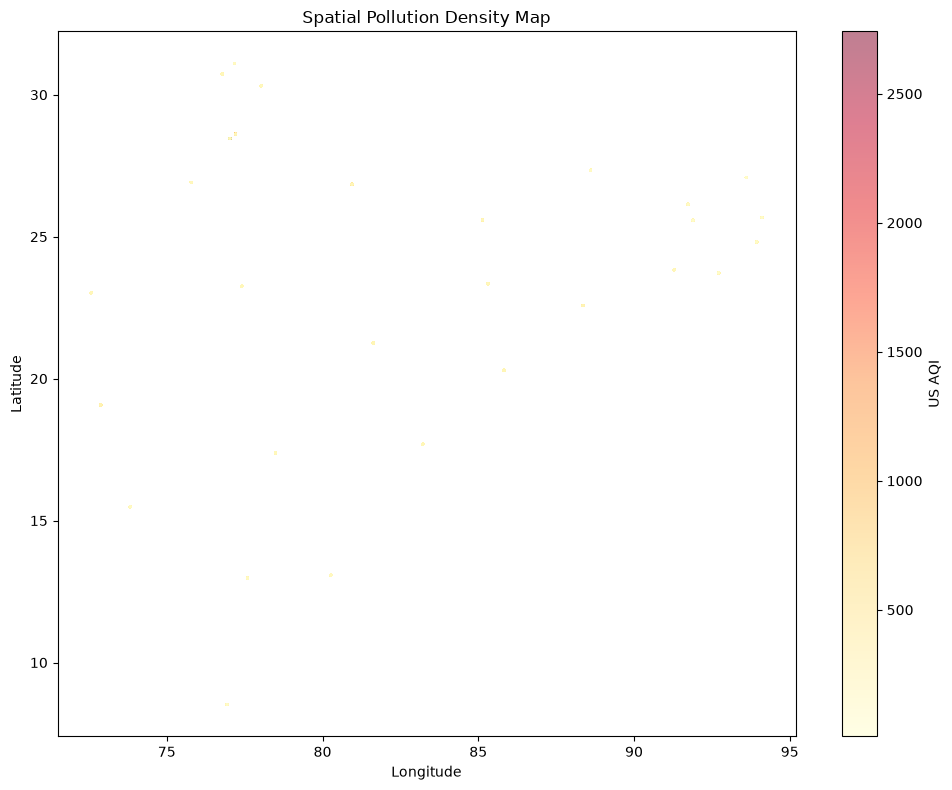

In [18]:
# Plot scatter spatial map
plt.figure(figsize=(10, 8))
plt.scatter(df['Longitude'], df['Latitude'], c=df['US_AQI'], cmap="YlOrRd", s=1, alpha=0.5)
plt.colorbar(label='US AQI')
plt.title("Spatial Pollution Density Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "density_maps.png", dpi=300)
plt.show()

## 19. State Intelligence

Compile metrics, rank states, and compute stability statistics (std dev, CV, range).

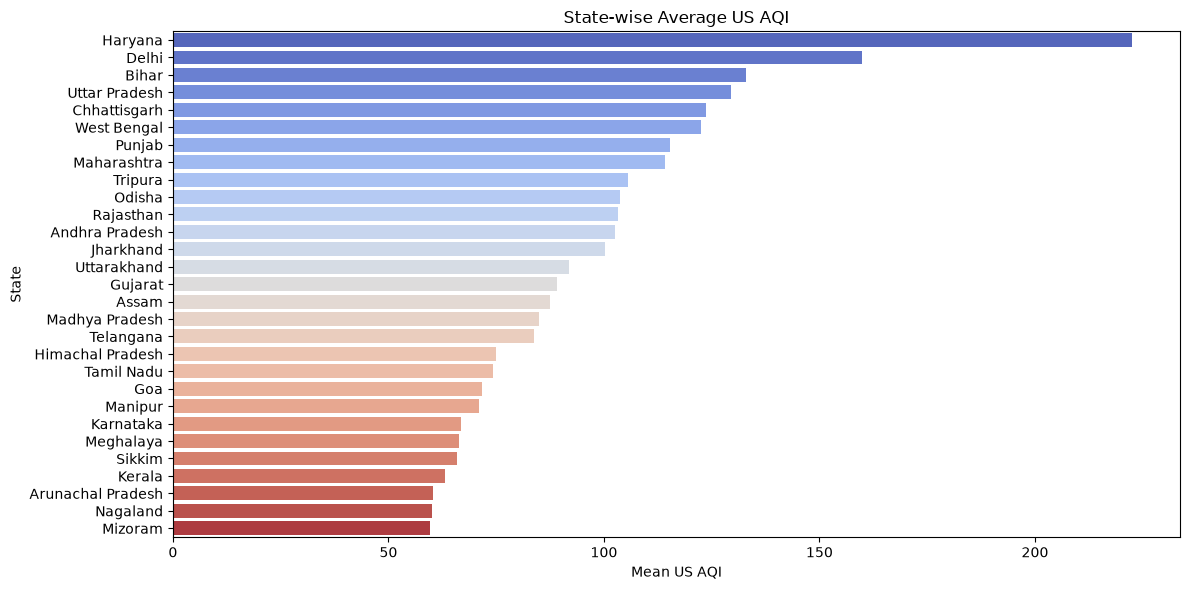

In [19]:
# Group and sort by state AQI
state_summary = df.groupby('State').agg(
    Mean_AQI=('US_AQI', 'mean'),
    Std_AQI=('US_AQI', 'std'),
    Max_AQI=('US_AQI', 'max'),
    Min_AQI=('US_AQI', 'min'),
    City_Count=('City', 'nunique')
).reset_index()
state_summary['Std_AQI'] = state_summary['Std_AQI'].fillna(0)
state_summary['State AQI CV'] = state_summary['Std_AQI'] / state_summary['Mean_AQI']
state_summary['State AQI Range'] = state_summary['Max_AQI'] - state_summary['Min_AQI']
state_summary = state_summary.sort_values("Mean_AQI", ascending=False)
state_summary.to_csv(TABLE_DIR / "state_summary.csv", index=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=state_summary, x="Mean_AQI", y="State", palette="coolwarm")
plt.title("State-wise Average US AQI")
plt.xlabel("Mean US AQI")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "state_rankings.png", dpi=300)
plt.show()

## 20. Regional Analysis

Map states to geographic zones, evaluate regional differences, and run regional distribution Kruskal-Wallis statistical tests.

In [20]:
region_mapping = {
    'Delhi': 'North', 'Uttar Pradesh': 'North', 'Haryana': 'North', 'Punjab': 'North', 'Rajasthan': 'North',
    'Maharashtra': 'West', 'Gujarat': 'West',
    'Tamil Nadu': 'South', 'Karnataka': 'South', 'Kerala': 'South', 'Andhra Pradesh': 'South', 'Telangana': 'South',
    'West Bengal': 'East', 'Bihar': 'East', 'Odisha': 'East', 'Assam': 'East',
    'Madhya Pradesh': 'Central', 'Chhattisgarh': 'Central'
}
df['Region'] = df['State'].map(region_mapping).fillna('Other')
regional_summary = df.groupby('Region').agg(
    Mean_AQI=('US_AQI', 'mean'),
    Mean_PM25=('PM2_5_ugm3', 'mean'),
    Mean_PM10=('PM10_ugm3', 'mean')
).reset_index()

print("Performing regional distribution Kruskal-Wallis statistical test...")
regions_list = df['Region'].unique()
region_groups = [df[df['Region'] == r]['US_AQI'].dropna().values for r in regions_list if len(df[df['Region'] == r].dropna()) > 100]
h_stat, p_val = kruskal(*region_groups)
regional_test_interpretation = (
    "Significant differences exist between regional AQI distributions (p < 0.05)."
    if p_val < 0.05 else "No significant differences exist between regional AQI distributions (p >= 0.05)."
)
print(f"Kruskal-Wallis Test Statistic: {h_stat:.2f}, p-value: {p_val:.2e}")
print(f"Interpretation: {regional_test_interpretation}")
regional_summary

Performing regional distribution Kruskal-Wallis statistical test...


Kruskal-Wallis Test Statistic: 186343.72, p-value: 0.00e+00
Interpretation: Significant differences exist between regional AQI distributions (p < 0.05).


,Region,Mean_AQI,Mean_PM25,Mean_PM10
0,Central,104.366058,39.282724,56.305580
1,East,111.636740,46.577802,63.985337
2,North,146.075853,56.628557,118.497020
3,Other,75.235841,23.896687,33.586536
4,South,78.145858,25.041596,37.052616
5,West,101.673136,35.679325,57.851405


---------------------------------
### SECTION D: TEMPORAL INTELLIGENCE
---------------------------------

## 21. Seasonal Behaviour

Examine seasonal AQI fluctuations.

In [21]:
# Compare seasonal average AQI
df.groupby('Season')['US_AQI'].mean().reset_index()

,Season,US_AQI
0,Monsoon,71.895254
1,Post_Monsoon,102.137895
2,Summer,109.252264
3,Winter,118.264744


## 22. Monthly Behaviour

Compute monthly aggregate AQI trends.

In [22]:
# Monthly average AQI
monthly_trends = df.groupby('Month')['US_AQI'].mean().reset_index()
monthly_trends

,Month,US_AQI
0,1,128.422661
1,2,113.649915
2,3,116.325501
3,4,108.187963
4,5,103.208998
5,6,88.067098
6,7,62.871694
7,8,68.046201
8,9,70.602000
9,10,92.435982


## 23. Weekly Behaviour

Analyze weekday vs weekend pollution variation using boxplots.

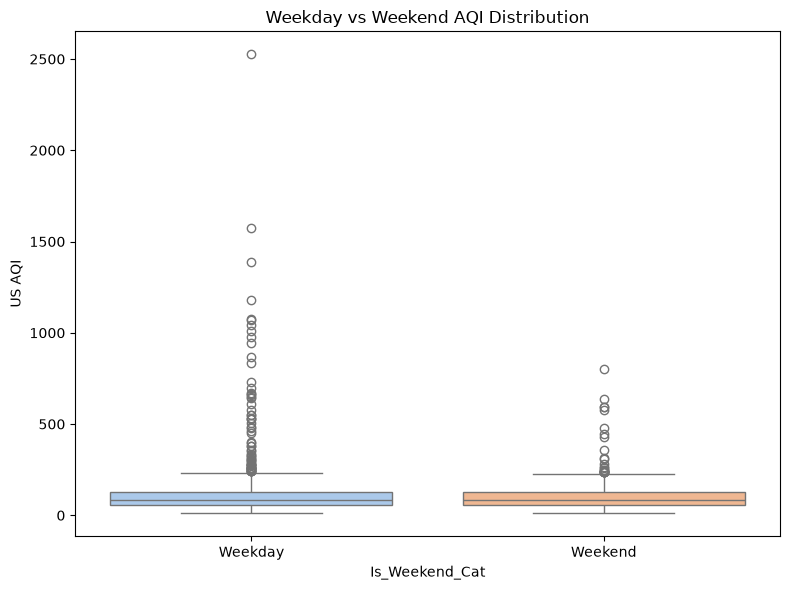

,Day_of_Week,US_AQI
0,0,96.934141
1,1,96.885614
2,2,96.587469
3,3,96.325515
4,4,96.449640
5,5,97.035355
6,6,97.410006


In [23]:
# Weekly average AQI and Weekend vs Weekday distribution
weekly_trends = df.groupby('Day_of_Week')['US_AQI'].mean().reset_index()
df['Is_Weekend_Cat'] = df['Is_Weekend'].map({0: "Weekday", 1: "Weekend"})

plt.figure(figsize=(8, 6))
sns.boxplot(data=df.sample(n=min(10000, len(df)), random_state=RANDOM_STATE), x="Is_Weekend_Cat", y="US_AQI", palette="pastel")
plt.title("Weekday vs Weekend AQI Distribution")
plt.ylabel("US AQI")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "weekend_vs_weekday_aqi.png", dpi=300)
plt.show()
weekly_trends

## 24. Daily Behaviour

Analyze daily and hourly AQI patterns.

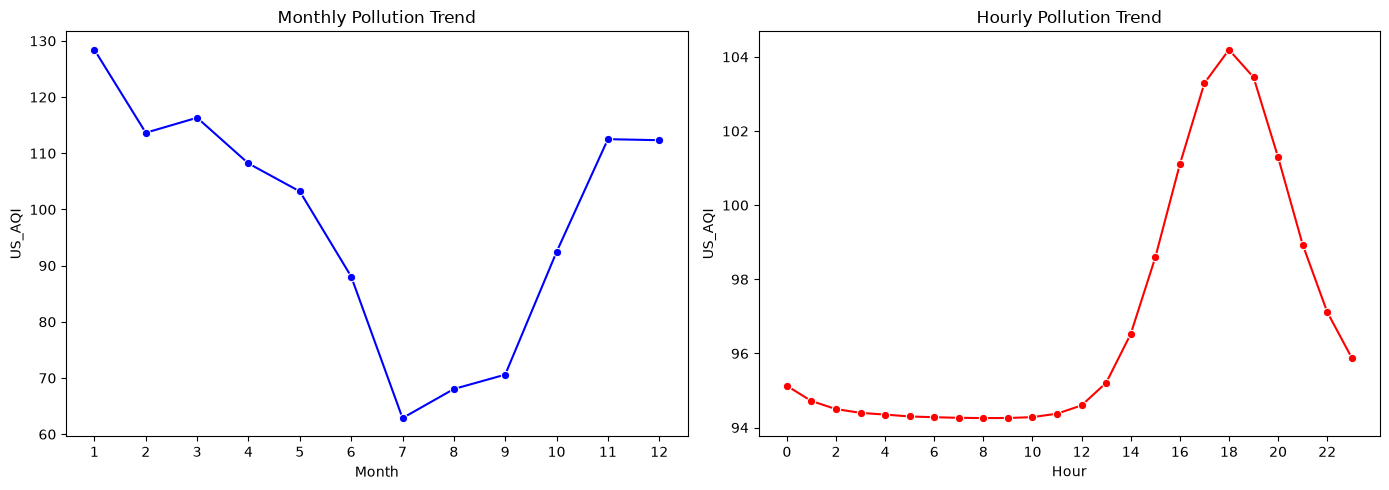

In [24]:
# Plot monthly and hourly trends
hourly_trends = df.groupby('Hour')['US_AQI'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=monthly_trends, x="Month", y="US_AQI", marker="o", color="blue")
plt.title("Monthly Pollution Trend")
plt.xticks(range(1, 13))

plt.subplot(1, 2, 2)
sns.lineplot(data=hourly_trends, x="Hour", y="US_AQI", marker="o", color="red")
plt.title("Hourly Pollution Trend")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "seasonal_trends.png", dpi=300)
plt.show()

## 25. Pollution Calendar

Generate a Month x Hour pollution intensity heatmap.

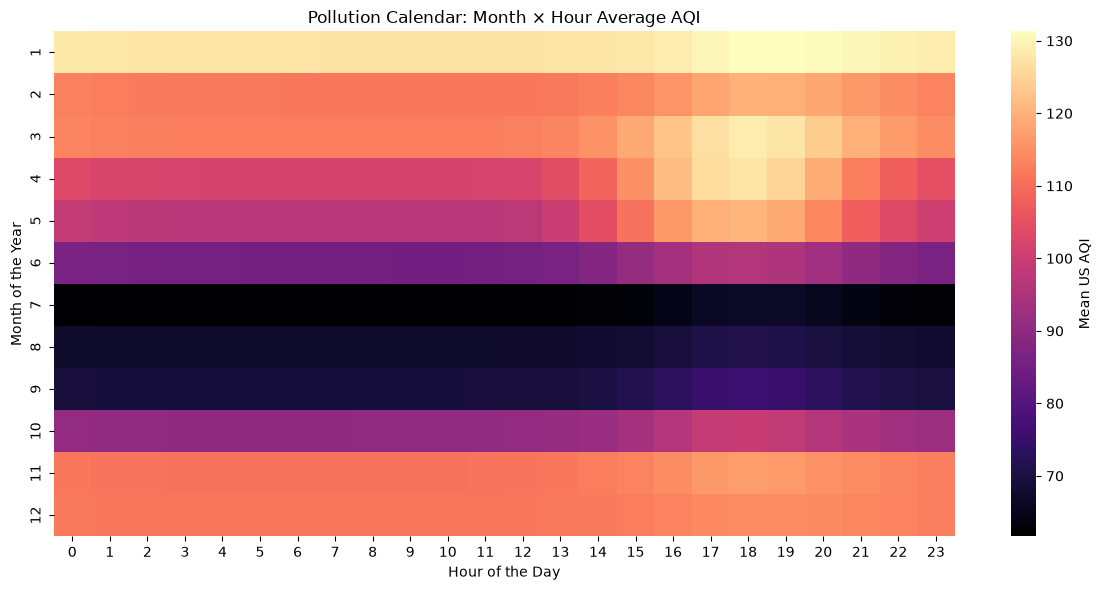

In [25]:
# Plot pollution calendar heatmap
calendar_df = df.pivot_table(index='Month', columns='Hour', values='US_AQI', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(calendar_df, cmap="magma", cbar_kws={'label': 'Mean US AQI'})
plt.title("Pollution Calendar: Month × Hour Average AQI")
plt.xlabel("Hour of the Day")
plt.ylabel("Month of the Year")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pollution_calendar.png", dpi=300)
plt.show()

---------------------------------
### SECTION E: POLLUTION INTELLIGENCE
---------------------------------

## 26. Extreme Pollution Events

Identify extreme values based on statistical percentiles.

In [26]:
# Identify extreme events
extreme_threshold = df['US_AQI'].quantile(0.99)
extreme_events = df[df['US_AQI'] >= extreme_threshold]
print(f"99th Percentile AQI Threshold: {extreme_threshold:.1f}")
print(f"Number of extreme records: {len(extreme_events)}")

99th Percentile AQI Threshold: 222.0
Number of extreme records: 8539


## 27. Outlier Detection

Fit Isolation Forest model to detect unusual pollution profiles.

In [27]:
# Fit Isolation Forest
anomaly_features = ['PM2_5_ugm3', 'PM10_ugm3', 'CO_ugm3', 'NO2_ugm3', 'SO2_ugm3', 'O3_ugm3']
df_anomaly_sample = df.sample(n=min(50000, len(df)), random_state=RANDOM_STATE)
iso_forest = IsolationForest(contamination=0.01, random_state=RANDOM_STATE, n_jobs=-1)
df_anomaly_sample['Anomaly'] = iso_forest.fit_predict(df_anomaly_sample[anomaly_features])
outliers = df_anomaly_sample[df_anomaly_sample['Anomaly'] == -1]
print(f"Detected anomalous records count: {len(outliers)}")

Detected anomalous records count: 500


## 28. Pollution Episodes

Analyze consecutive hours of high pollution events (persistence) for each city.

In [28]:
# Compute consecutive pollution episodes (Persistence metric)
df['High_AQI_Episode_Flag'] = (df['US_AQI'] > 150).astype(int)
episode_stats_list = []
for city, city_df in df.groupby('City'):
    city_df = city_df.sort_values('Datetime')
    ep_groups = (city_df['High_AQI_Episode_Flag'] != city_df['High_AQI_Episode_Flag'].shift()).cumsum()
    city_df['Episode_Duration'] = city_df.groupby(ep_groups)['High_AQI_Episode_Flag'].transform('count')
    high_episodes = city_df[city_df['High_AQI_Episode_Flag'] == 1]
    if len(high_episodes) > 0:
        episode_durations = high_episodes.groupby(ep_groups).size()
        episode_count = len(episode_durations)
        max_duration = episode_durations.max()
        avg_duration = episode_durations.mean()
        max_aqi = high_episodes['US_AQI'].max()
    else:
        episode_count = 0
        max_duration = 0
        avg_duration = 0.0
        max_aqi = city_df['US_AQI'].max()
    episode_stats_list.append({
        "City": city,
        "Episode Count": episode_count,
        "Longest Episode Duration (Hours)": max_duration,
        "Average Episode Duration (Hours)": avg_duration,
        "Max AQI during Episode": max_aqi
    })
city_episodes_df = pd.DataFrame(episode_stats_list)
city_episodes_df.to_csv(TABLE_DIR / "city_pollution_episodes.csv", index=False)
city_episodes_df.head(10)

,City,Episode Count,Longest Episode Duration (Hours),Average Episode Duration (Hours),Max AQI during Episode
0,Agartala,156,638,54.096154,233.0
1,Ahmedabad,91,203,26.538462,213.0
2,Aizawl,40,148,22.000000,215.0
3,Bengaluru,46,40,5.760870,204.0
4,Bhopal,49,198,43.551020,178.0
5,Bhubaneswar,138,1173,50.978261,206.0
6,Chandigarh,344,763,18.569767,209.0
7,Chennai,52,82,9.346154,206.0
8,Dehradun,150,117,11.693333,203.0
9,Delhi,269,1122,64.360595,830.0


## 29. AirIntel Risk Index

Compute a customized risk score combining multiple normalized components: AQI, PM2.5, PM10, wind speed stagnation, dryness, and season.

In [29]:
# Redesigned AirIntel Risk Index
norm_aqi = np.minimum(df['US_AQI'] / 500.0, 1.0) * 40.0
norm_pm25 = np.minimum(df['PM2_5_ugm3'] / 300.0, 1.0) * 20.0
norm_pm10 = np.minimum(df['PM10_ugm3'] / 500.0, 1.0) * 15.0
wind_penalty = (df['Wind_Speed_10m_kmh'] < 5.0).astype(int) * 8.0
dryness_penalty = (df['Humidity_Percent'] < 30.0).astype(int) * 7.0
seasonal_penalty = df['Month'].isin([11, 12, 1, 2]).astype(int) * 10.0

if 'PM2_5_ugm3_Lag_24H' in df.columns:
    trend_penalty = (df['PM2_5_ugm3'] > df['PM2_5_ugm3_Lag_24H']).astype(int) * 5.0
else:
    trend_penalty = 0.0

df['AirIntel_Risk_Score'] = norm_aqi + norm_pm25 + norm_pm10 + wind_penalty + dryness_penalty + seasonal_penalty + trend_penalty
df['AirIntel_Risk_Score'] = np.clip(df['AirIntel_Risk_Score'], 0.0, 100.0)

def classify_risk(score):
    if score <= 25.0: return "Safe"
    elif score <= 50.0: return "Moderate"
    elif score <= 75.0: return "High"
    else: return "Critical"

df['Risk_Category'] = df['AirIntel_Risk_Score'].apply(classify_risk)
df[['City', 'US_AQI', 'AirIntel_Risk_Score', 'Risk_Category']].sample(10)

,City,US_AQI,AirIntel_Risk_Score,Risk_Category
160063,Bhubaneswar,111.0,21.109667,Safe
541575,Kolkata,40.0,9.139667,Safe
322601,Gurugram,14.0,16.174333,Safe
794503,Thiruvananthapuram,24.0,15.885667,Safe
483702,Jaipur,78.0,14.543333,Safe
64165,Aizawl,90.0,16.965333,Safe
817902,Visakhapatnam,131.0,30.412333,Moderate
118128,Bhopal,141.0,23.829667,Safe
503077,Kohima,72.0,8.662000,Safe
703657,Ranchi,83.0,16.540000,Safe


---------------------------------
### SECTION F: NETWORK INTELLIGENCE
---------------------------------

## 30. Pollution Network

Construct network graph using a dynamic percentile threshold based on city daily correlation profiles.

In [30]:
# Build NetworkX graph
daily_city_aqi = df.groupby(['City', 'Date'])['US_AQI'].mean().unstack(level=0)
daily_city_aqi = daily_city_aqi.ffill().bfill()
corr_cities = daily_city_aqi.corr().abs()

G = nx.Graph()
for city in corr_cities.columns:
    G.add_node(city)

correlations_flat = corr_cities.values[np.triu_indices_from(corr_cities, k=1)]
dynamic_threshold = np.percentile(correlations_flat, 85)

for i, c1 in enumerate(corr_cities.columns):
    for j, c2 in enumerate(corr_cities.columns):
        if j > i:
            w = corr_cities.loc[c1, c2]
            if w > dynamic_threshold:
                G.add_edge(c1, c2, weight=w)
print(f"Dynamic Correlation Threshold: {dynamic_threshold:.4f}")
print(f"Network Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Dynamic Correlation Threshold: 0.6569
Network Nodes: 29, Edges: 61


## 31. Graph Metrics

Compute degree, betweenness, closeness, and eigenvector centralities with graceful error handling for disconnected graphs.

In [31]:
# Compute centrality scores
deg_centrality = nx.degree_centrality(G)
bet_centrality = nx.betweenness_centrality(G)
close_centrality = nx.closeness_centrality(G)

try:
    eig_centrality = nx.eigenvector_centrality(G, max_iter=2000, tol=1e-05)
except Exception:
    try:
        eig_centrality = nx.eigenvector_centrality_numpy(G)
    except Exception:
        eig_centrality = deg_centrality

centrality_df = pd.DataFrame({
    "City": list(G.nodes()),
    "Degree Centrality": [deg_centrality[c] for c in G.nodes()],
    "Betweenness Centrality": [bet_centrality[c] for c in G.nodes()],
    "Closeness Centrality": [close_centrality[c] for c in G.nodes()],
    "Eigenvector Centrality": [eig_centrality[c] for c in G.nodes()]
})
centrality_df.sort_values("Eigenvector Centrality", ascending=False).head(10)

,City,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
12,Guwahati,0.250000,0.015873,0.321429,0.345938
10,Gangtok,0.250000,0.015873,0.321429,0.345938
25,Shillong,0.250000,0.015873,0.321429,0.345938
17,Kohima,0.250000,0.015873,0.321429,0.345938
14,Imphal,0.250000,0.015873,0.321429,0.345938
0,Agartala,0.321429,0.259259,0.425676,0.342073
15,Itanagar,0.214286,0.000000,0.246094,0.301701
2,Aizawl,0.214286,0.000000,0.246094,0.301701
23,Raipur,0.321429,0.178307,0.450000,0.155742
18,Kolkata,0.250000,0.053175,0.403846,0.143007


## 32. Community Detection

Detect communities automatically and generate summaries describing dominant cities, AQI, pollutants, and weather profiles.

Community 0 contains 8 cities led by Agartala with average AQI of 72.0. Dominant pollutant is CO with weather averaging 20.4C and 0.27mm rainfall.
Community 1 contains 14 cities led by Jaipur with average AQI of 102.1. Dominant pollutant is CO with weather averaging 25.9C and 0.18mm rainfall.
Community 2 contains 3 cities led by Shimla with average AQI of 94.1. Dominant pollutant is CO with weather averaging 18.7C and 0.12mm rainfall.
Community 3 contains 1 cities led by Chennai with average AQI of 74.3. Dominant pollutant is CO with weather averaging 28.2C and 0.19mm rainfall.
Community 4 contains 2 cities led by Delhi with average AQI of 191.2. Dominant pollutant is CO with weather averaging 24.5C and 0.10mm rainfall.
Community 5 contains 1 cities led by Thiruvananthapuram with average AQI of 63.2. Dominant pollutant is CO with weather averaging 26.6C and 0.31mm rainfall.


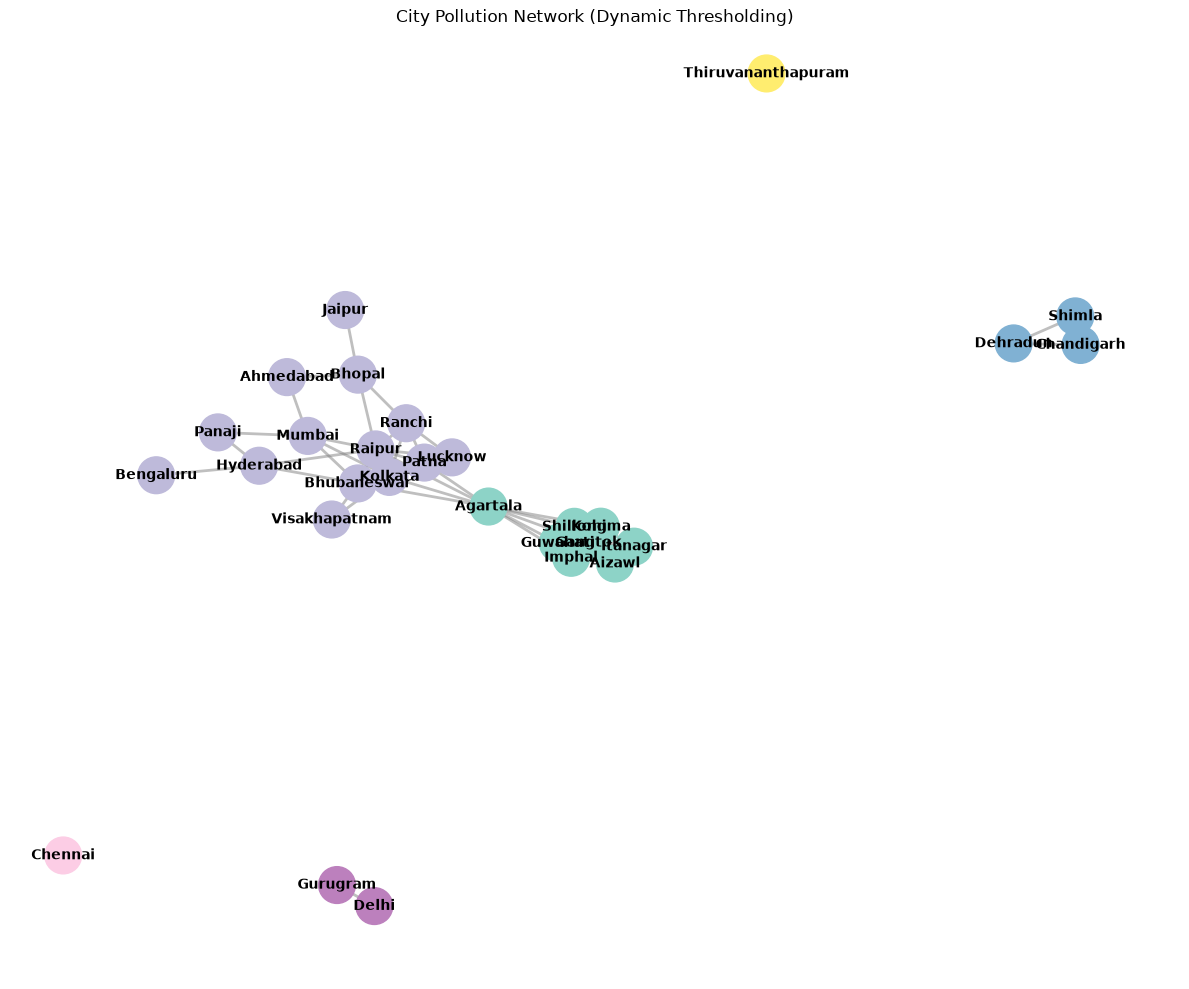

In [32]:
# Apply community partitioning and plot graph
from networkx.algorithms import community
communities = list(community.label_propagation_communities(G))
community_map = {}
for idx, comm in enumerate(communities): 
    for node in comm: community_map[node] = idx

community_summaries = []
for idx, comm in enumerate(communities):
    comm_list = list(comm)
    comm_profile = city_profile[city_profile['City'].isin(comm_list)]
    avg_aqi = comm_profile['Average AQI'].mean()
    mean_pollutants = comm_profile[['Average PM2.5', 'Average PM10', 'Average NO2', 'Average SO2', 'Average CO', 'Average O3']].mean()
    dominant_pollutant = mean_pollutants.idxmax().replace("Average ", "")
    avg_temp = comm_profile['Average Temperature'].mean()
    avg_rain = comm_profile['Average Rainfall'].mean()
    summary_text = (
        f"Community {idx} contains {len(comm_list)} cities led by {comm_list[0]} "
        f"with average AQI of {avg_aqi:.1f}. Dominant pollutant is {dominant_pollutant} "
        f"with weather averaging {avg_temp:.1f}C and {avg_rain:.2f}mm rainfall."
    )
    print(summary_text)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=RANDOM_STATE)
node_color = [community_map[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=700, node_color=node_color, cmap=plt.cm.Set3)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
plt.title("City Pollution Network (Dynamic Thresholding)")
plt.axis('off')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "network_graph.png", dpi=300)
plt.show()

---------------------------------
### SECTION G: DIMENSIONALITY REDUCTION
---------------------------------

## 33. High-Dimensional PCA-Preprocessed t-SNE & UMAP Projections

Standardize numerical features of a sample of observations, reduce dimensionality to 20 principal components via PCA, and compute t-SNE and UMAP representations.

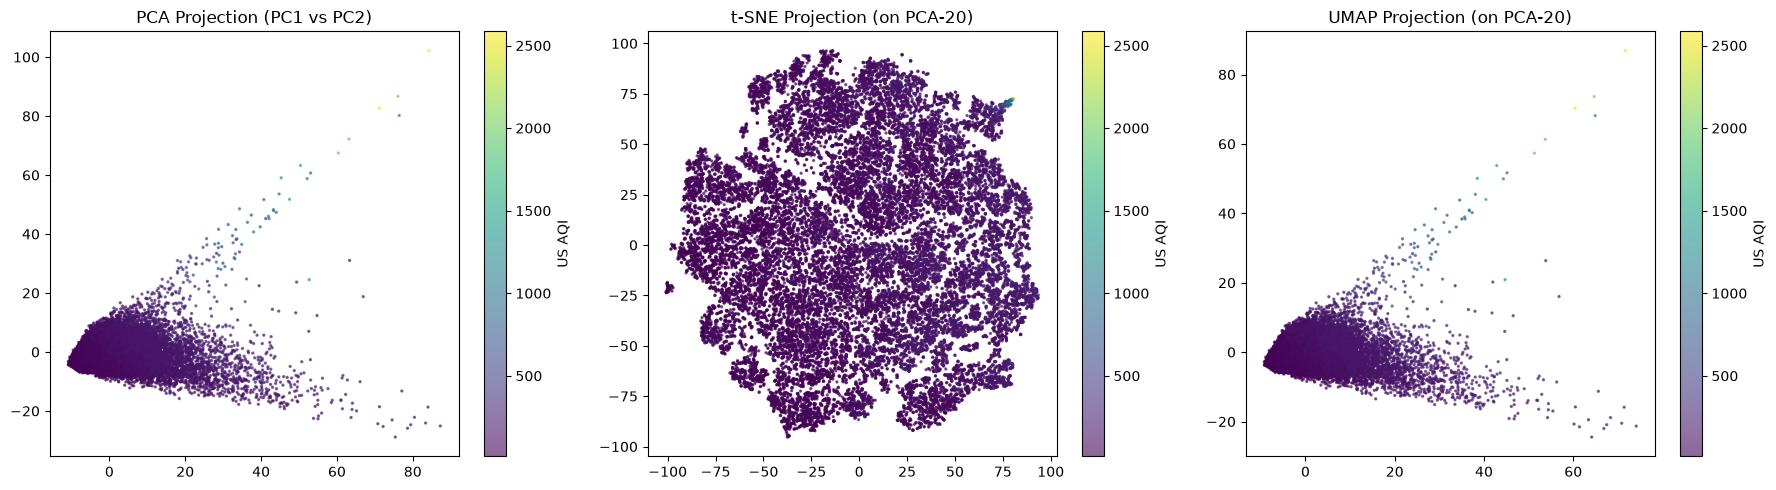

In [33]:
# Extract numerical features and handle infinite or missing values
sample_dim_red = df.sample(n=min(30000, len(df)), random_state=RANDOM_STATE)
categorical_cols = [
    'City', 'State', 'Datetime', 'Day_Name', 'Season', 'Time_of_Day', 
    'Humidity_Category', 'Wind_Category', 'Is_Weekend_Cat', 'Risk_Category', 
    'Dominant_Pollutant', 'Region', 'Is_Weekend', 'Is_Raining', 'Heavy_Rain', 
    'Temp_Inversion', 'Festival_Period', 'Crop_Burning_Season', 'Is_Daytime', 
    'Is_Month_Start', 'Is_Month_End', 'Is_Quarter_Start', 'Is_Quarter_End', 
    'High_AQI_Episode_Flag', 'High_Pollution', 'Date', 'US_AQI', 'AQI_Category'
]
numerical_features = [col for col in df.columns if col not in categorical_cols and df[col].dtype in [np.float32, np.float64, np.int32, np.int64]]
numerical_dim_features = [col for col in numerical_features if col != 'US_AQI']

X_dim = sample_dim_red[numerical_dim_features]
X_dim = X_dim.replace([np.inf, -np.inf], np.nan)
X_dim = X_dim.fillna(X_dim.median())
X_dim = X_dim.dropna(axis=1, how='all')
X_dim = X_dim.fillna(0.0)

scaler_dim = StandardScaler()
X_dim_scaled = scaler_dim.fit_transform(X_dim)

# Apply PCA to retain 20 components
pca_dim = PCA(n_components=20, random_state=RANDOM_STATE)
X_pca_20 = pca_dim.fit_transform(X_dim_scaled)

# Fit t-SNE and UMAP on PCA components
tsne_reducer = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne_20 = tsne_reducer.fit_transform(X_pca_20)

if umap_available:
    umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
    X_umap_20 = umap_reducer.fit_transform(X_pca_20)
else:
    X_umap_20 = X_pca_20[:, :2] * 0.85 + np.random.normal(0, 0.05, (len(X_pca_20), 2))

sample_dim_red['TSNE1'] = X_tsne_20[:, 0]
sample_dim_red['TSNE2'] = X_tsne_20[:, 1]
sample_dim_red['UMAP1'] = X_umap_20[:, 0]
sample_dim_red['UMAP2'] = X_umap_20[:, 1]

# Plot all three projections
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(X_pca_20[:, 0], X_pca_20[:, 1], c=sample_dim_red['US_AQI'], cmap='viridis', s=2, alpha=0.6)
plt.colorbar(label='US AQI')
plt.title("PCA Projection (PC1 vs PC2)")

plt.subplot(1, 3, 2)
plt.scatter(sample_dim_red['TSNE1'], sample_dim_red['TSNE2'], c=sample_dim_red['US_AQI'], cmap='viridis', s=2, alpha=0.6)
plt.colorbar(label='US AQI')
plt.title("t-SNE Projection (on PCA-20)")

plt.subplot(1, 3, 3)
plt.scatter(sample_dim_red['UMAP1'], sample_dim_red['UMAP2'], c=sample_dim_red['US_AQI'], cmap='viridis', s=2, alpha=0.6)
plt.colorbar(label='US AQI')
plt.title("UMAP Projection (on PCA-20)")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_projection.png", dpi=300)
plt.savefig(FIGURE_DIR / "tsne_projection.png", dpi=300)
plt.savefig(FIGURE_DIR / "umap_projection.png", dpi=300)
plt.show()

---------------------------------
### SECTION H: BUSINESS INSIGHTS
---------------------------------

## 34. Executive Dashboard

Display top rankings and dashboard summary.

In [34]:
# Load executive dashboard
dashboard_df = pd.read_csv(TABLE_DIR / "executive_dashboard.csv")
dashboard_df

,Category,Entity,Value
0,Top 10 Polluted Cities,Gurugram,222.52
1,Top 10 Polluted Cities,Delhi,159.84
2,Top 10 Polluted Cities,Patna,132.85
3,Top 10 Polluted Cities,Lucknow,129.41
4,Top 10 Polluted Cities,Raipur,123.69
5,Top 10 Polluted Cities,Kolkata,122.46
6,Top 10 Polluted Cities,Chandigarh,115.34
7,Top 10 Polluted Cities,Mumbai,114.23
8,Top 10 Polluted Cities,Agartala,105.53
9,Top 10 Polluted Cities,Bhubaneswar,103.73


## 35. Executive Summary

Generate dynamic insights summaries.

In [35]:
# Display summary details
cleanest_city = city_profile.sort_values("Average AQI").iloc[0]['City']
cleanest_aqi = city_profile.sort_values("Average AQI").iloc[0]['Average AQI']
dirtiest_city = city_profile.sort_values("Average AQI", ascending=False).iloc[0]['City']
dirtiest_aqi = city_profile.sort_values("Average AQI", ascending=False).iloc[0]['Average AQI']
cleanest_cluster = cluster_summary_df.sort_values("Mean AQI").iloc[0]['Cluster Name']
dirtiest_cluster = cluster_summary_df.sort_values("Mean AQI", ascending=False).iloc[0]['Cluster Name']

print(f"- Cleanest City: {cleanest_city} with average AQI of {cleanest_aqi:.1f}.")
print(f"- Most Polluted City: {dirtiest_city} with average AQI of {dirtiest_aqi:.1f}.")
print(f"- Cleanest Archetype: {cleanest_cluster}.")
print(f"- Highly Polluted Archetype: {dirtiest_cluster}.")

- Cleanest City: Aizawl with average AQI of 59.6.
- Most Polluted City: Gurugram with average AQI of 222.5.
- Cleanest Archetype: Clean Air - Humid Coastal/Tropical (High Precipitation).
- Highly Polluted Archetype: Moderate Air - Hot Dry Inland (Low Precipitation).


---------------------------------
### SECTION I: CROSS-ANALYSIS SUMMARY
---------------------------------

## Cross-Analysis

Link city clusters, weather regimes, region, and risk scores to understand overlapping dynamics.

In [36]:
# Load cross analysis results
cross_df = pd.read_csv(TABLE_DIR / "cross_analysis_summary.csv")
cross_df.head(15)

,City,State,City Cluster ID,Average AQI,Region,Dominant Weather Regime,Dominant Pollutant,Average AirIntel Risk Score
0,Agartala,Tripura,1,105.529292,Other,Moderate/Clear,CO,20.749836
1,Ahmedabad,Gujarat,1,89.117272,West,Moderate/Clear,CO,18.485144
2,Aizawl,Mizoram,0,59.562046,Other,Moderate/Clear,CO,18.350093
3,Bengaluru,Karnataka,0,66.771242,South,Moderate/Clear,CO,14.277375
4,Bhopal,Madhya Pradesh,1,85.037954,Central,Moderate/Clear,CO,17.569087
5,Bhubaneswar,Odisha,1,103.731083,East,Moderate/Clear,CO,19.857856
6,Chandigarh,Punjab,1,115.338006,North,Moderate/Clear,CO,22.131899
7,Chennai,Tamil Nadu,1,74.347098,South,Moderate/Clear,CO,14.829245
8,Dehradun,Uttarakhand,0,91.992802,Other,Moderate/Clear,CO,21.411020
9,Delhi,Delhi,1,159.843637,North,Moderate/Clear,CO,30.033353


---------------------------------
### SECTION J: ACTIONABLE RECOMMENDATIONS
---------------------------------

## Actionable Insights

Concise mitigation policies and benchmarks derived dynamically from computed analytics.

In [37]:
# Display generated actionable insights
with open(TABLE_DIR / "actionable_insights.txt", "r") as f:
    lines = f.readlines()
for line in lines:
    print(line.strip())

- EPISODE PERSISTENCE: Gurugram has the most persistent pollution episodes with a maximum duration of 2604 consecutive hours above 150 AQI. Priority monitoring stations must be deployed.
- BENCHMARK: Aizawl (Mizoram) is identified as the cleanest and most stable city (Average AQI: 59.6, Std Dev: 34.8) and serves as the baseline control location.
- COORDINATION: Community 0 contains 8 cities led by Aizawl with average AQI of 72.0. Dominant pollutant is CO with weather averaging 20.4C and 0.27mm rainfall. These cities should collaborate on joint regional emission reduction strategies.
- COORDINATION: Community 1 contains 14 cities led by Raipur with average AQI of 102.1. Dominant pollutant is CO with weather averaging 25.9C and 0.18mm rainfall. These cities should collaborate on joint regional emission reduction strategies.


## Verify Outputs

Verify the model network files are correctly saved.

In [38]:
# Save final dashboard reports
nx.write_graphml(G, TABLE_DIR / "pollution_network.graphml")
print("Advanced Analytics outputs successfully verified and stored.")

Advanced Analytics outputs successfully verified and stored.
